# Titanic Survival Prediction - CodSoft Data Science Internship

## Project Overview

This project focuses on predicting whether a passenger survived the Titanic disaster using Machine Learning techniques.

The model analyzes passenger information such as:
- Age
- Gender
- Passenger Class
- Fare
- Family Members
- Embarkation Point

The objective is to build a classification model that can predict survival outcomes based on historical passenger data.

In [60]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [61]:
# Loading Titanic dataset

df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Dataset Description

The dataset contains information about Titanic passengers.

Important features include:

- survived: Survival status (0 = No, 1 = Yes)
- pclass: Passenger class
- sex: Gender
- age: Passenger age
- fare: Ticket fare
- embarked: Boarding location

In [62]:
df.shape

(891, 15)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [64]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [65]:
# Filling missing age values

df['age'].fillna(
    df['age'].median(),
    inplace=True
)


# Filling missing embarked values

df['embarked'].fillna(
    df['embarked'].mode()[0],
    inplace=True
)


# Removing unnecessary column

df.drop(
    ['deck'],
    axis=1,
    inplace=True
)


df.isnull().sum()

/tmp/ipykernel_1166/3022870125.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(
/tmp/ipykernel_1166/3022870125.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value},

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


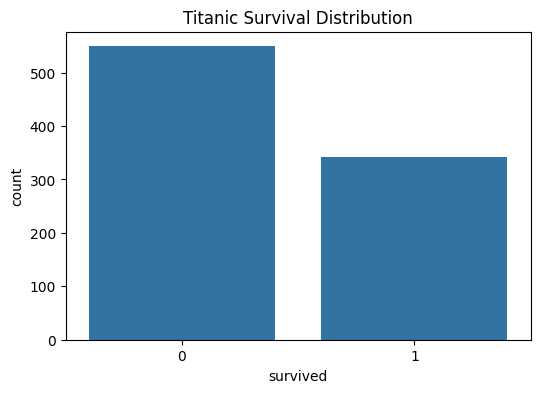

In [66]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='survived',
    data=df
)

plt.title("Titanic Survival Distribution")

plt.show()

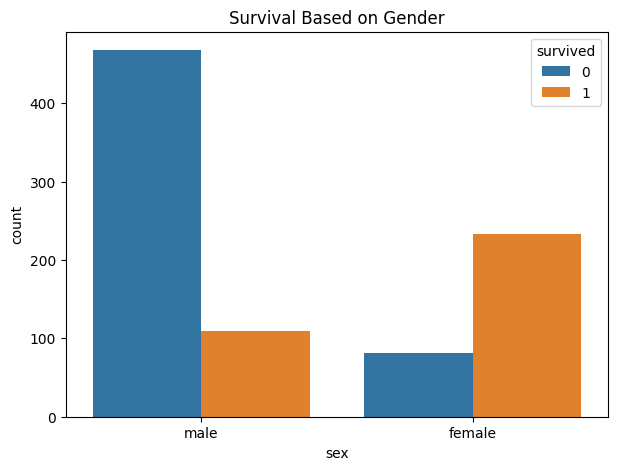

In [67]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='sex',
    hue='survived',
    data=df
)

plt.title("Survival Based on Gender")

plt.show()

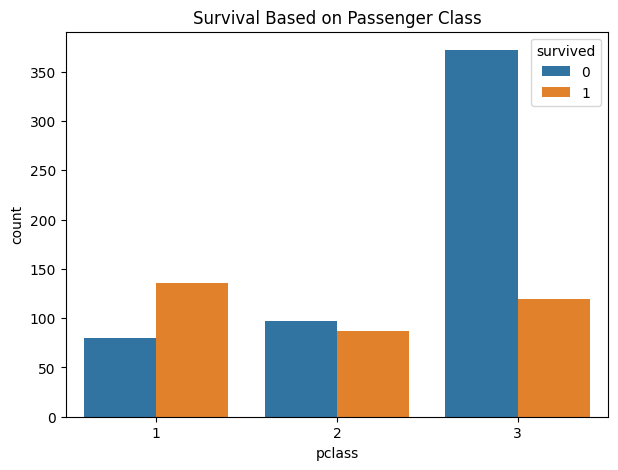

In [68]:
plt.figure(figsize=(7,5))

sns.countplot(
    x='pclass',
    hue='survived',
    data=df
)

plt.title("Survival Based on Passenger Class")

plt.show()

In [69]:
encoder = LabelEncoder()


df['sex'] = encoder.fit_transform(df['sex'])

df['embarked'] = encoder.fit_transform(df['embarked'])

In [70]:
X = df[
[
'sex',
'age',
'pclass',
'fare',
'sibsp',
'parch',
'embarked'
]
]


y = df['survived']

In [71]:
X_train, X_test, y_train, y_test = train_test_split(

X,
y,
test_size=0.2,
random_state=42

)

In [72]:
scaler = StandardScaler()


X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [73]:
from sklearn.linear_model import LogisticRegression

# Instantiate the model (assuming X_train, y_train, X_test are already defined from previous cells)
model = LogisticRegression(max_iter=200) # Re-instantiate model

# Fit the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

In [74]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Re-run data loading and preprocessing to ensure y_test and y_pred are defined
df = sns.load_dataset('titanic')

# Filling missing age values
df['age'].fillna(df['age'].median(), inplace=True)
# Filling missing embarked values
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
# Removing unnecessary column
df.drop(['deck'], axis=1, inplace=True)

# Encode categorical features
encoder = LabelEncoder()
df['sex'] = encoder.fit_transform(df['sex'])
df['embarked'] = encoder.fit_transform(df['embarked'])

# Define features (X) and target (y)
X = df[['sex', 'age', 'pclass', 'fare', 'sibsp', 'parch', 'embarked']]
y = df['survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the model (Logistic Regression as inferred from imports)
model = LogisticRegression(max_iter=200) # Added max_iter to prevent potential convergence warning

# Fit the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate and print accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)


print(
"Model Accuracy:",
accuracy*100,
"%"
)

Model Accuracy: 80.44692737430168 %


/tmp/ipykernel_1166/909502862.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_1166/909502862.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [75]:
print(
classification_report(
y_test,
y_pred
)
)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



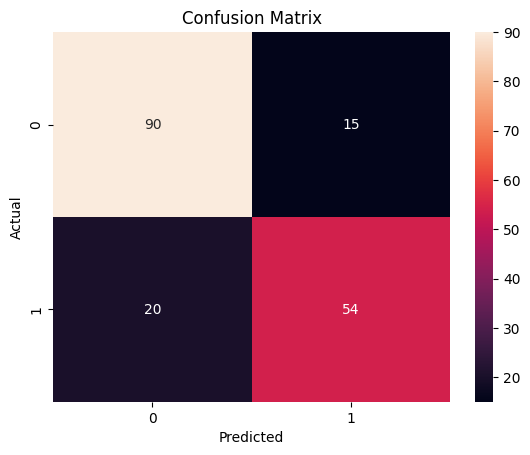

In [76]:
cm = confusion_matrix(
y_test,
y_pred
)


sns.heatmap(
cm,
annot=True,
fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Conclusion

The Titanic Survival Prediction project successfully demonstrates the application of Machine Learning classification techniques.

After performing data preprocessing, visualization, and model training, the Logistic Regression model was able to predict passenger survival with good accuracy.

This project shows how Data Science can be used to analyze historical data and generate meaningful predictions.